# VCA simulator: checkpoint 1 validation

This notebook checks the `vca_sim` core against everything we can check it against today:

1. **Plant presets** reproduce the greybox notebook's numbers.
2. **Drive model** (command → reported current) fitted on the plain chirps, where the PC's command is known exactly.
3. **Whole chain** (command → drive → plant → laser), simulated chirp against the rig chirp: this sets the laser delay.
4. **Sensor noise** defaults against the 0 A idle windows.
5. **Closed loop**: the firmware PI on the linear plant against the analytic results in `position-control.md`, and the loop-gain measurement against the analytic loop gain.
6. **What the firmware PI looks like** on the best model with the measured drive: margins and tracking in the 35–55 Hz band.
7. **Export**: a simulated run read back by `vca_log.load_log`.

What it can **not** check yet: closed-loop accuracy against the rig. No closed-loop log exists; the first PI run on the rig should be replayed here.

In [1]:
import sys, glob, math
from dataclasses import replace
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, ".")
from vca_log import load_log
from vca_sim import *
from vca_sim import references as R, analysis as AN, calibration as C, replay as RP
pd.set_option("display.precision", 4)
PI = load_controller("controllers/position_pi.py")
OL = load_controller("controllers/open_loop_current.py")
CHIRPS = {"train": "data/train/voice_coil_log_chirp_6.5A_1.0to55.0Hz_120.0s_20261002_093641.csv",
          "test": "data/test/voice_coil_log_chirp_6.0A_1.0to55.0Hz_120.0s_20261002_094200.csv"}

## 1. Plant presets

Small-signal values at each model's rest position, and the range of motion each was fitted on (its validity envelope; runs outside it get a warning).

In [2]:
rows = []
for key, p in PRESETS.items():
    ss = p.small_signal()
    rows.append({"preset": key, **{k: ss[k] for k in ("x0_mm", "k_N_per_m", "Kf_N_per_A", "f_n_Hz", "zeta", "static_gain_mm_per_A")},
                 "c": p.params["c"], "fitted x range (mm)": f"{p.envelope.x_min_mm:+.1f}..{p.envelope.x_max_mm:+.1f}",
                 "fitted band (Hz)": f"{p.envelope.f_min_hz:g}-{p.envelope.f_max_hz:g}"})
pd.DataFrame(rows).set_index("preset")

,x0_mm,k_N_per_m,Kf_N_per_A,f_n_Hz,zeta,static_gain_mm_per_A,c,fitted x range (mm),fitted band (Hz)
preset,,,,,,,,,
greybox_C,-0.0817,60487.3193,233.5676,5.4544,0.6016,3.8614,2123.6525,-5.7..+6.5,10-55
greybox_A,0.0000,58562.6645,235.3264,5.3669,0.6142,4.0184,2133.4779,-5.7..+6.5,10-55
greybox_B,0.0000,64264.6190,231.0442,5.6222,0.5785,3.5952,2104.9042,-5.7..+6.5,10-55
sysid_poly5,-0.6660,39609.9688,250.1293,4.4139,0.6696,6.3148,1912.6093,-16.0..+16.0,1-55
linear_msd,0.0000,35500.0000,250.0000,4.1786,0.4290,7.0423,1160.0000,-10.0..+10.0,0-100
datasheet,0.0000,41171.0548,283.0000,4.5000,0.3983,6.8738,1160.0000,-18.0..+18.0,0-100


**Greybox NRMSE reproduced.** Same preprocessing as `vca_greybox_fit.load` and the same 1 ms RK4 rollouts from the measured state, on the test scheduled chirp. Expected (notebook printout): A 0.003, 0.180, 0.642, 0.594; B 0.003, 0.183, 0.803, 0.783; C 0.003, 0.180, 0.640, 0.587.

In [3]:
d = RP.load_greybox(next(Path("data/test").glob("voice_coil_log_chirpsched_*.csv")))
pd.DataFrame({key: RP.rollout_nrmse(PRESETS[key], d, d["sweep"], H=1000)[[1, 10, 100, 1000]]
              for key in ("greybox_A", "greybox_B", "greybox_C")}, index=["k=1", "k=10", "k=100", "k=1000"]).T

,k=1,k=10,k=100,k=1000
greybox_A,0.0027,0.1798,0.6425,0.5935
greybox_B,0.0027,0.1830,0.8031,0.7829
greybox_C,0.0027,0.1800,0.6397,0.5872


## 2. Drive: command → reported current

In current mode the PC sends `experiment_target_current_A(t_k)`, which is rebuilt exactly from the file name. Fitted model: 2 whole cycles of delay, then a **shelf**, gain `gain_dc` at low frequency and `gain_hf` above about 6 Hz. So the "0.87" of the in-band notebook is not a fixed scaling error: at 2 Hz the gain is 1.0.

Also found here: **KP is 60 A**, not 120 A (command step 1.831 mA = 60/32768, reported-current step 7.32 mA = 60/8192).

,delay_ticks,gain_dc,gain_hf,shelf_tau_s,lag_s,rms_A
train,2.0,1.0094,0.8508,0.0252,1.1101e-05,0.2582
test,2.0,1.0104,0.8466,0.0261,2.8221e-05,0.2315


defaults in DriveConfig: {'kp_A': 60.0, 'gain_dc': 1.01, 'gain_hf': 0.849, 'shelf_tau_s': 0.0256, 'lag_s': 0.0, 'delay_ticks': 2}


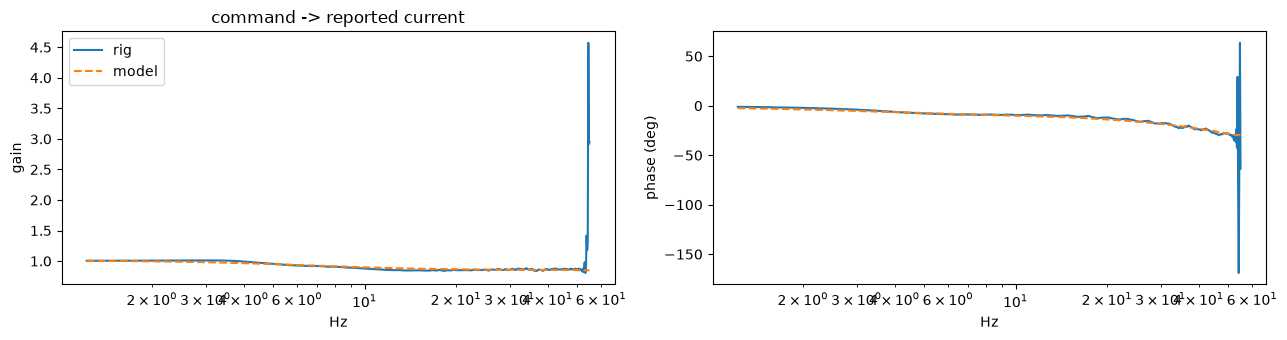

In [4]:
fits = {}
for split, p in CHIRPS.items():
    r = load_log(p).run
    cmd = RP.reference_from_log_name(p).evaluate(r.time_s.to_numpy()).r
    fits[split] = C.fit_drive(cmd, r.actual_current_A.to_numpy(), delays=[1, 2, 3])[0]
display(pd.DataFrame(fits).T)
print("defaults in DriveConfig:", {k: v for k, v in DriveConfig().describe().items() if k in ("gain_dc", "gain_hf", "shelf_tau_s", "lag_s", "delay_ticks", "kp_A")})

# frequency response, rig against the fitted model
p = CHIRPS["train"]; r = load_log(p).run; t = r.time_s.to_numpy()
cmd = RP.reference_from_log_name(p).evaluate(t).r
dc = DriveConfig()
model = C.drive_report(cmd, dc.gain_dc, dc.gain_hf, dc.shelf_tau_s, dc.delay_ticks, dc.lag_s)
f, Hr, coh = C.frf(cmd, r.actual_current_A.to_numpy()); _, Hm, _ = C.frf(cmd, model)
band = (f >= 1) & (f <= 55)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
ax[0].plot(f[band], abs(Hr[band]), label="rig"); ax[0].plot(f[band], abs(Hm[band]), "--", label="model")
ax[0].set(xscale="log", xlabel="Hz", ylabel="gain", title="command -> reported current"); ax[0].legend()
ax[1].plot(f[band], np.degrees(np.angle(Hr[band])), label="rig"); ax[1].plot(f[band], np.degrees(np.angle(Hm[band])), "--", label="model")
ax[1].set(xscale="log", xlabel="Hz", ylabel="phase (deg)"); plt.tight_layout(); plt.show()

The model leaves about 0.23–0.26 A rms unexplained (about 5 % of the signal). The residual does not follow velocity (back-EMF) or position. It is not modelled and is listed as an open question.

## 3. Whole chain: command → logged position

The plain chirps simulated through the complete chain: playback controller, drive, plant, and laser. The laser is noise-free here, and its delay is set to 0 so that the phase difference reads directly as the missing delay.

The rig moves ±14–16 mm below 10 Hz, outside every model's fitted range. Greybox A and the 23 Sep polynomial model leave the stroke there, because neither hardens towards the walls. Only greybox C runs through. The comparison that matters is in band.

In [5]:
rows = []
for split, p in CHIRPS.items():
    r = load_log(p).run; t = r.time_s.to_numpy(); cmd = RP.reference_from_log_name(p).evaluate(t).r
    for key in ("greybox_C", "greybox_A", "sysid_poly5"):
        sc = RP.scenario_from_log(p, OL, PRESETS[key], idle_s=0.0, laser=replace(NOISE_FREE_LASER, delay_s=0.0))
        res = simulate(sc)
        if not res.ok:
            print(f"{split} {key}: {res.message}"); continue
        for q in C.compare_position_frf(t, cmd, r.position_mm.to_numpy(), res.t, res["target_current_A"], res["position_mm"],
                                        f_eval=(12, 16, 20, 25, 30, 38, 42, 46)):
            rows.append({"run": split, "model": key, **q})
tab = pd.DataFrame(rows)
tab.pivot_table(index="f_Hz", columns="run", values=["gain_ratio", "delay_diff_ms", "coherence_rig"])

train greybox_A: true position +21.18 mm passed the 21.0 mm stroke guard after t = 0.1385 s


train sysid_poly5: true position -21.05 mm passed the 21.0 mm stroke guard after t = 0.6400 s


test greybox_A: true position +21.10 mm passed the 21.0 mm stroke guard after t = 0.1450 s


test sysid_poly5: true position -21.03 mm passed the 21.0 mm stroke guard after t = 0.6465 s


coherence_rig         delay_diff_ms         gain_ratio        
run           test   train          test   train       test   train
f_Hz                                                               
12          0.8888  0.8621        3.5679  3.9017     0.9684  0.9730
16          0.8584  0.8488        2.2999  2.3606     0.9448  0.9294
20          0.8729  0.8485        1.5835  1.6578     0.9324  0.9158
25          0.8555  0.8172        1.3200  1.5908     0.9317  0.9117
30          0.7531  0.6513        1.4104  1.3525     0.9322  0.9362
38          0.6286  0.5492        1.1009  1.1742     0.8133  0.8391
42          0.5114  0.3965        1.1065  1.1581     0.8191  0.8705
46          0.5598  0.5102        1.1501  1.1973     0.8518  0.8970

- **Laser delay.** The simulation leads the rig by a steady 1.10–1.20 ms at 38–46 Hz, so the default `LaserConfig.delay_s` is 1.15 ms. Below 30 Hz the difference grows: the plant's own phase is off there.
- **Amplitude in band.** The simulated chain moves only 0.81–0.90 of the rig's amplitude at 38–46 Hz. This agrees with the in-band notebook, where the laser-derived Kf is 270–280 N/A against greybox C's 234. A controller tuned in simulation will therefore see about 10–20 % more plant gain on the rig in this band. The 35.5 Hz laser-mount mode (coherence dip at 38 Hz) is in no model.

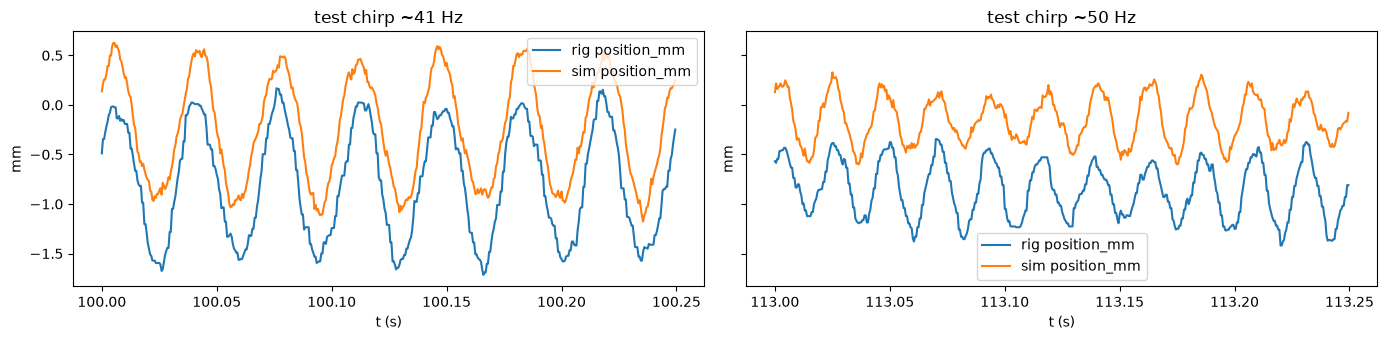

In [6]:
# time traces in band with the default (calibrated) sensors and noise, test chirp
p = CHIRPS["test"]; r = load_log(p).run
res = simulate(RP.scenario_from_log(p, OL, PRESETS["greybox_C"]))
fig, ax = plt.subplots(1, 2, figsize=(14, 3.5), sharey=True)
for a_, (t0, lab) in zip(ax, [(100.0, "~41 Hz"), (113.0, "~50 Hz")]):
    m_r = (r.time_s >= t0) & (r.time_s < t0 + 0.25); m_s = (res.t >= t0) & (res.t < t0 + 0.25)
    a_.plot(r.time_s[m_r], r.position_mm[m_r], label="rig position_mm"); a_.plot(res.t[m_s], res["position_mm"][m_s], label="sim position_mm")
    a_.set(title=f"test chirp {lab}", xlabel="t (s)", ylabel="mm"); a_.legend()
plt.tight_layout(); plt.show()

## 4. Sensor noise in the 0 A idle windows

In [7]:
rows = []
for p in sorted(glob.glob("data/*/voice_coil_log_*.csv")):
    lg = load_log(p)
    if len(lg.idle):
        rows.append({"log": Path(p).name[15:45], **C.idle_noise(lg.idle.position_mm, lg.idle.ai2_value_V, lg.idle.actual_current_A)})
display(pd.DataFrame(rows).set_index("log"))
L, A, D = LaserConfig(), AccelConfig(), DriveConfig()
print(f"defaults: laser white {L.noise_mm} mm, 50 Hz {L.mains_amp_mm} mm, 150 Hz {L.mains3_amp_mm} mm; accel {A.noise_V} V; current {D.report_noise_A} A")

,mains_hz,mains_amp_mm,mains3_amp_mm,white_mm,position_std_mm,accel_std_V,current_std_A
log,,,,,,,
chirp_6.0A_1.0to55.0Hz_120.0s_,50.045,0.0929,0.0488,0.0240,0.0780,0.0055,0.0230
chirpsched_0.0s3.0A-30.0s7.0A-,49.975,0.0926,0.0476,0.0239,0.0774,0.0054,0.0234
chirp_6.5A_1.0to55.0Hz_120.0s_,49.990,0.0938,0.0489,0.0219,0.0779,0.0053,0.0238
chirpsched_0.0s2.0A-30.0s6.0A-,50.000,0.0887,0.0496,0.0264,0.0766,0.0055,0.0226


defaults: laser white 0.024 mm, 50 Hz 0.092 mm, 150 Hz 0.049 mm; accel 0.0054 V; current 0.023 A


## 5. Closed loop against known results

These are the firmware PI (`controllers/position_pi.py`, a copy of `pi_update`) on the linear mass-spring-damper. The claims come from `docs/position-control.md` on the `position_control` branch, and `tests/test_validation.py` asserts each of them:

| Claim | Check |
|---|---|
| Ki stability limit 0.62 A/(mm·s) at c = 197, Kp = 0.02 | stable at 0.5× the limit, growing at 2× |
| Time constant about 0.8 s at Kp 0.02 / Ki 0.2 | 63 % rise time of a step |
| Closed-loop mode near 12 Hz at Kp = 1 | crossover of the measured loop gain |

The loop-gain measurement itself is checked against the analytic sampled-data loop gain.

ideal drive: max |L_sim / L_analytic - 1| = 4.1e-06;  margins [{'f_Hz': 11.551817714604773, 'phase_margin_deg': 11.800443309116481, 'delay_margin_ms': 2.8375628841985847}]


2-cycle delay: max |L_sim / L_analytic - 1| = 6.4e-05;  margins [{'f_Hz': 11.551816580814645, 'phase_margin_deg': 7.613133093848633, 'delay_margin_ms': 1.8306724123787954}]


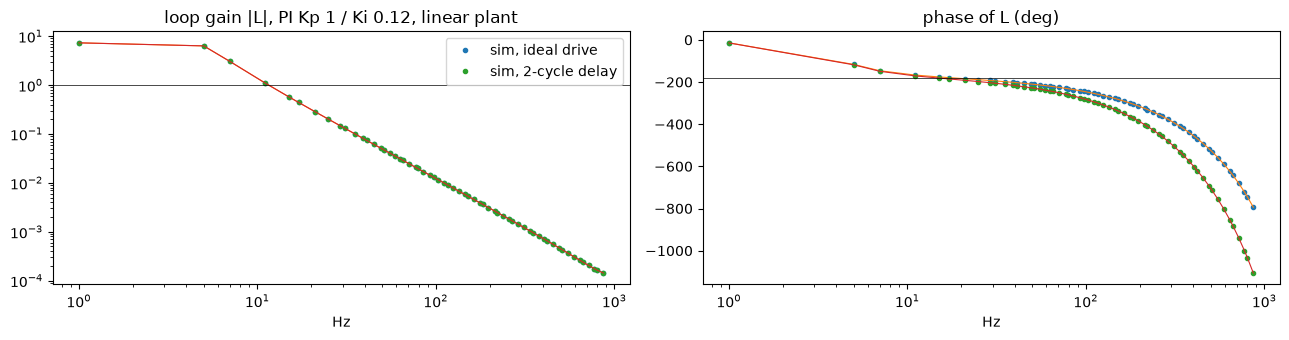

Ki limit at c = 197, Kp = 0.02: 0.6196893203883496


step 0 -> 1 mm at Kp 0.02 / Ki 0.2: 63 % after 0.70 s (doc: time constant about 0.8 s)


In [8]:
sc = Scenario(PI, {"Kp": 1.0, "Ki": 0.12}, R.Constant(0.0), PRESETS["linear_msd"], IDEAL_DRIVE, NOISE_FREE_LASER, NOISE_FREE_ACCEL)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
for drive, lab in ((IDEAL_DRIVE, "ideal drive"), (replace(IDEAL_DRIVE, delay_ticks=2), "2-cycle delay")):
    lg = AN.loop_gain(replace(sc, drive=drive), rms_A=0.05)
    La = AN.msd_pi_loop_gain(lg.f_hz, sc.plant.params, 1.0, 0.12, sc.dt_s, drive.delay_ticks, sc.laser.delay_s)
    print(f"{lab}: max |L_sim / L_analytic - 1| = {np.max(np.abs(lg.L / La - 1)):.1e};  margins {lg.margins['crossovers']}")
    ax[0].loglog(lg.f_hz, abs(lg.L), "o", ms=3, label=f"sim, {lab}"); ax[0].loglog(lg.f_hz, abs(La), "-", lw=0.8)
    ax[1].semilogx(lg.f_hz, np.degrees(np.unwrap(np.angle(lg.L))), "o", ms=3); ax[1].semilogx(lg.f_hz, np.degrees(np.unwrap(np.angle(La))), "-", lw=0.8)
ax[0].axhline(1, color="k", lw=0.5); ax[0].set(title="loop gain |L|, PI Kp 1 / Ki 0.12, linear plant", xlabel="Hz"); ax[0].legend()
ax[1].axhline(-180, color="k", lw=0.5); ax[1].set(title="phase of L (deg)", xlabel="Hz"); plt.tight_layout(); plt.show()

p = PRESETS["linear_msd"].with_params(c=197.0).params
print("Ki limit at c = 197, Kp = 0.02:", p["c"] * (p["k1"] + 0.02 * p["kf0"] * 1000) / (p["m"] * p["kf0"] * 1000))
res = simulate(Scenario(PI, {"Kp": 0.02, "Ki": 0.2}, R.Steps(((0.0, 0.0), (1.0, 1.0))), PRESETS["linear_msd"], IDEAL_DRIVE,
                        NOISE_FREE_LASER, NOISE_FREE_ACCEL, duration_s=6.0))
t63 = res.t[np.argmax((res.t > 1) & (res["x_true_mm"] >= 0.632))] - 1
print(f"step 0 -> 1 mm at Kp 0.02 / Ki 0.2: 63 % after {t63:.2f} s (doc: time constant about 0.8 s)")

## 6. The firmware PI with everything switched on

This run uses the firmware gains (Kp 1.0, Ki 0.12) on greybox C, with the measured drive, laser noise and quantisation. The comparison is drive by drive, because the drive delay is what the earlier analysis in `position-control.md` treated as negligible.

In [9]:
base = Scenario(PI, {"Kp": 1.0, "Ki": 0.12}, R.Constant(0.0), PRESETS["greybox_C"])
rows = []
for key in ("greybox_C", "linear_msd", "sysid_poly5"):
    for drive, lab in ((DriveConfig(), "measured"), (IDEAL_DRIVE, "ideal")):
        lg = AN.loop_gain(replace(base, plant=PRESETS[key], drive=drive), rms_A=0.2)
        c0 = lg.margins["crossovers"][0] if lg.margins.get("crossovers") else {}
        rows.append({"plant": key, "drive": lab, "status": lg.status, "crossover_Hz": c0.get("f_Hz"),
                     "phase_margin_deg": c0.get("phase_margin_deg"), "delay_margin_ms": c0.get("delay_margin_ms"),
                     "modulus_margin": lg.margins.get("modulus_margin")})
pd.DataFrame(rows)

,plant,drive,status,crossover_Hz,phase_margin_deg,delay_margin_ms,modulus_margin
0,greybox_C,measured,ok,10.3058,26.9907,7.2750,0.3825
1,greybox_C,ideal,ok,10.9274,31.1570,7.9202,0.5173
2,linear_msd,measured,ok,10.9455,5.0619,1.2846,0.0845
3,linear_msd,ideal,ok,11.5531,11.8374,2.8461,0.2670
4,sysid_poly5,measured,ok,10.4901,19.3593,5.1263,0.2910
5,sysid_poly5,ideal,ok,11.1167,24.6568,6.1611,0.4391


ok [] {'status': 'ok', 'duration_s': 4.9995, 'rms_error_true_mm': 0.23561579699264001, 'max_error_true_mm': 1.8201050526954259, 'rms_error_measured_mm': 0.25052595094525415, 'rms_current_A': 0.25198534657008503, 'peak_current_A': 1.8482294898437515, 'max_abs_position_mm': 1.6653000819376806}


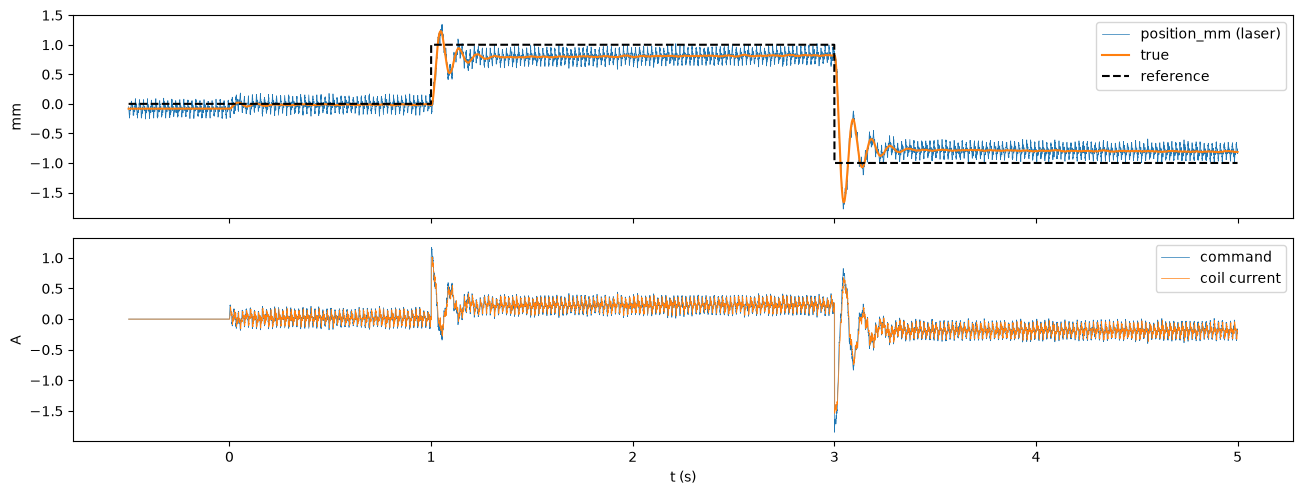

In [10]:
res = simulate(replace(base, reference=R.Steps(((0.0, 0.0), (1.0, 1.0), (3.0, -1.0))), duration_s=5.0, idle_s=0.5))
print(res.status, res.warnings, AN.tracking_metrics(res, settle_s=0.5))
fig, ax = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
ax[0].plot(res.t, res["position_mm"], lw=0.5, label="position_mm (laser)"); ax[0].plot(res.t, res["x_true_mm"], label="true")
ax[0].plot(res.t, res["ref"], "k--", label="reference"); ax[0].set(ylabel="mm"); ax[0].legend()
ax[1].plot(res.t, res["u_cmd_A"], lw=0.5, label="command"); ax[1].plot(res.t, res["i_true_A"], lw=0.5, label="coil current")
ax[1].set(xlabel="t (s)", ylabel="A"); ax[1].legend(); plt.tight_layout(); plt.show()

**Tracking in the application band.** These are stepped sines of ±0.5 mm. `mass_line_current_A` is the current the moving mass alone needs at that amplitude. That is a floor for any controller, and it sits against the drive's 60 A peak and the PI's 10 A clamp.

In [11]:
rows = AN.tracking_response(base, [35, 40, 45, 50, 55], amplitude_mm=0.5, duration_s=2.0)
pd.DataFrame(rows).set_index("f_Hz")

,status,mass_line_current_A,gain_true,phase_true_deg,converged,gain_measured,phase_measured_deg,peak_current_A
f_Hz,,,,,,,,
35.0,ok,5.3316,0.0875,164.5792,True,0.0946,151.2890,0.7337
40.0,ok,6.9638,0.0654,160.8659,True,0.0649,148.0539,0.6797
45.0,ok,8.8135,0.0505,157.7029,False,0.0428,161.9610,0.7048
50.0,ok,10.8809,0.0383,163.5152,True,0.1510,-73.3117,0.5612
55.0,ok,13.1659,0.0331,148.5748,True,0.0460,107.0511,0.6871


## 7. Export to the rig log format

In [12]:
res = simulate(replace(base, reference=R.Sine(0.0, 1.0, 5.0), duration_s=1.0, idle_s=0.5))
path = RP.write_rig_csv(res, Path("gcsc_data") / "sim" / "voice_coil_log_sim_posPI_sine1mm5Hz.csv")
lg = load_log(path)
print(path, "| load_log:", len(lg.run), "run rows,", len(lg.idle), "idle rows; bias", round(lg.bias_V, 4), "V; extra columns:",
      [c for c in lg.run.columns][13:])

gcsc_data\sim\voice_coil_log_sim_posPI_sine1mm5Hz.csv | load_log: 2000 run rows, 1000 idle rows; bias 0.6552 V; extra columns: ['position_ref_mm', 'controller_output_A', 'ctrl_p_A', 'ctrl_i_A', 'ctrl_position_filt_mm', 'sim_true_position_mm', 'sim_true_current_A']


## Findings at checkpoint 1

- **The model presets reproduce the notebooks.** Greybox A, B and C match the printed test NRMSE.
- **The drive is a shelf, not a fixed 0.87.** Its gain is about 1.01 at DC and 0.85 above about 10 Hz (time constant about 25 ms), with 2 whole cycles of delay before the coil current and one more before it is reported.
  - KP is 60 A.
  - About 5 % of the reported current is still unexplained.
- **The whole chain lines up in band once the laser delay is 1.15 ms.**
  - The total delay from PC command to logged position is about 2.6–2.7 ms. That is the drive's 3 cycles plus the sensor, plus about 0.5 ms that comes from how the plant fits were discretised.
  - In band the models move 10–20 % less than the rig, consistent with the in-band notebook's Kf of 270–280 N/A.
- **The closed-loop machinery is exact against theory.** The loop gain matches the analytic value to better than 1e-4, and the three PI claims of `position-control.md` hold on the linear plant.
- **At Kp = 1 the firmware PI's margin depends on which damping estimate is right.**
  - The crossover is near 10–12 Hz.
  - With the measured drive, greybox C (c ≈ 2100 N·s/m) has about 27° of phase margin and a delay margin of about 7 ms.
  - The linear plant with the datasheet c = 1160 has about 5° and 1.3 ms.
  - The drive's delay and shelf cost 4–7° of phase compared with an ideal drive.
  - The earlier statement that "1 ms of delay doesn't matter" holds at Kp = 0.02. At Kp = 1 it holds only if the damping is high, so measuring the damping (step-release or ring-down) matters before tuning further.
- **Not yet validated:** closed-loop behaviour against the rig. The first closed-loop log should be replayed through the tool.